# Russian River Step 3 -- 2D mesh

Form the 2D mesh, elevate via a DEM, condition.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [3]:
import os,sys
import logging
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pickle
import shapely
import pandas as pd
import geopandas as gpd
pd.options.display.max_columns = None
import copy

import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.condition
import watershed_workflow.dynamic_colormaps

# set the default figure size for notebooks
plt.rcParams["figure.figsize"] = (8, 6)

## Input: Parameters and other source data

In [4]:
# Force Watershed Workflow to pull data from this directory rather than a shared data directory.
# This picks up the Coweeta-specific datasets set up here to avoid large file downloads for 
# demonstration purposes.
#
def splitPathFull(path):
    """
    Splits an absolute path into a list of components such that
    os.path.join(*splitPathFull(path)) == path
    """
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:  # root on Unix or drive letter with backslash on Windows (e.g., C:\)
            parts.insert(0, head)
            break
        elif tail == path:  # just a single file or directory
            parts.insert(0, tail)
            break
        else:
            parts.insert(0, tail)
            path = head
    return parts

cwd = splitPathFull(os.getcwd())
assert cwd[-1] == 'workflow'
cwd = cwd[:-1]

# Note, this directory is where downloaded data will be put as well
data_dir = os.path.join(*(cwd + ['input_data',]))
def toInput(filename):
    return os.path.join(data_dir, filename)

output_dir = os.path.join(*(cwd + ['output_data',]))
output_filenames = dict()
def fromOutput(filename):
    return os.path.join(output_dir, filename)    

def toOutput(role, filename):
    output_filenames[role] = filename
    return fromOutput(filename)

# check output and input dirs exist
if not os.path.isdir(data_dir):
    os.makedirs(data_dir, exist_ok=True)
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)
       

In [5]:
# Set the data directory to the local space to get the locally downloaded files
# REMOVE THIS CELL for general use outside fo Coweeta
watershed_workflow.config.setDataDirectory(data_dir)


In [6]:
## Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed. 
name = 'RussianRiver'
hucs = ['18010110'] # a list of HUCs to run


# -- parameters to clean and reduce the river network prior to meshing
prune_by_area = 20               # km^2
simplify = 200                   # length scale to target average edge 

# -- mesh triangle refinement control
refine_d0 = 200
refine_d1 = 600

refine_L0 = 200
refine_L1 = 500

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2


# Refine triangles if they get too acute
min_angle = 20 # degrees

# width of reach by stream order (order:width)
river_widths = dict({1:10, 2:10, 3:20, 4:30, 5:30}) 


# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.default_crs

## Reload data

In [7]:
with open(fromOutput('03a_watersheds.pickle'), 'rb') as fid:
    watersheds = pickle.load(fid)

reaches = gpd.read_parquet(fromOutput('03b_rivers.parquet'))
rivers = watershed_workflow.river_tree.createRivers(reaches, method='native')


In [8]:
# load m2 mesh from file -- we will use this for testing pitfilling algorithms
with open(fromOutput('03b_m2_preconditioning_smoothed.pickle'), 'rb') as fid:
    m2_orig = pickle.load(fid)

In [9]:
assert not np.any(np.isnan(m2_orig.coords))

In [10]:
%pdb

# fill pits away from the river
outlet_edge = (0, 8106)
preserved_pits = [c for (c,conn) in enumerate(m2_orig.conn) if len(conn) > 3]

m2 = copy.deepcopy(m2_orig)
m2r, res = watershed_workflow.condition.conditionMesh(m2,
                                                     preserved_pits=preserved_pits,
                                                     forced_outlet_edges=[outlet_edge,],
                                                      divide_edges=[e for 
                                                     epsilon = 0.01
                                                    )

plt.show()

Automatic pdb calling has been turned ON


2026-02-04 21:07:38,140 - root - INFO: 
2026-02-04 21:07:38,141 - root - INFO: Running marching_iterative: 589 initial pits
2026-02-04 21:07:38,141 - root - INFO: ==============================================================================
2026-02-04 21:07:52,081 - root - INFO:  ... iteration 0 of marching: 66 pits
2026-02-04 21:08:04,749 - root - INFO:  ... iteration 1 of marching: 66 pits
2026-02-04 21:08:17,364 - root - INFO:  ... iteration 2 of marching: 66 pits
2026-02-04 21:08:17,365 - root - INFO:  ... done iterating, max iterations.
2026-02-04 21:08:18,284 - root - INFO:   completed: 66 final pits, 523 removed
2026-02-04 21:08:18,285 - root - INFO:     - 66 'internal' pits with max depth 6.776519775390625 and median 0.579775492350258
2026-02-04 21:08:18,285 - root - INFO:   RMSE of dz: 6.593145768493388
2026-02-04 21:08:18,285 - root - INFO:   MAE of dz: 0.8896544440404256
2026-02-04 21:08:18,285 - root - INFO:   MAX of dz: 127.85843017578111
2026-02-04 21:08:18,286 - root - 

In [11]:
res[-1]['pits_final']


[(41345, 'internal', np.float64(0.0), nan),
 (70040, 'internal', np.float64(-0.0049999999999954525), nan),
 (70042, 'internal', np.float64(-0.006975308641983702), nan),
 (70043, 'internal', np.float64(-0.0049999999999954525), nan),
 (71601, 'internal', np.float64(-0.0049999999999954525), nan),
 (72395, 'internal', np.float64(-0.0049999999999954525), nan),
 (73235, 'internal', np.float64(-0.005000000020942252), nan),
 (77568, 'internal', np.float64(-0.00986034380527201), nan),
 (77691, 'internal', np.float64(0.0), nan),
 (77697, 'internal', np.float64(0.0), nan),
 (77769, 'internal', np.float64(0.0), nan),
 (78082, 'internal', np.float64(-0.0049999999999954525), nan),
 (78083, 'internal', np.float64(-0.0049999999999954525), nan)]

In [12]:
# double-check...
pits = watershed_workflow.condition.findPits(m2r,
                                             forced_outlet_edges=[outlet_edge,])
for pit in pits:
    print(pit)

(73537, 'internal', np.float64(0.0001391827646841648), nan)
(73601, 'internal', np.float64(0.004765566263046139), nan)
(75323, 'internal', np.float64(0.0041156689013632786), nan)


Connected callback to axes: Axes(0.125,0.11;0.182353x0.77)
Adding non-symmetric group of size 2
... adding a wrapper of type <class 'matplotlib.collections.PolyCollection'>
... adding a wrapper of type <class 'matplotlib.collections.PolyCollection'>
Added a group with 2 wrappers
Now have 1 groups
Adding symmetric group of size 1
... adding a wrapper of type <class 'matplotlib.collections.PolyCollection'>
Added a group with 1 wrappers
Now have 2 groups


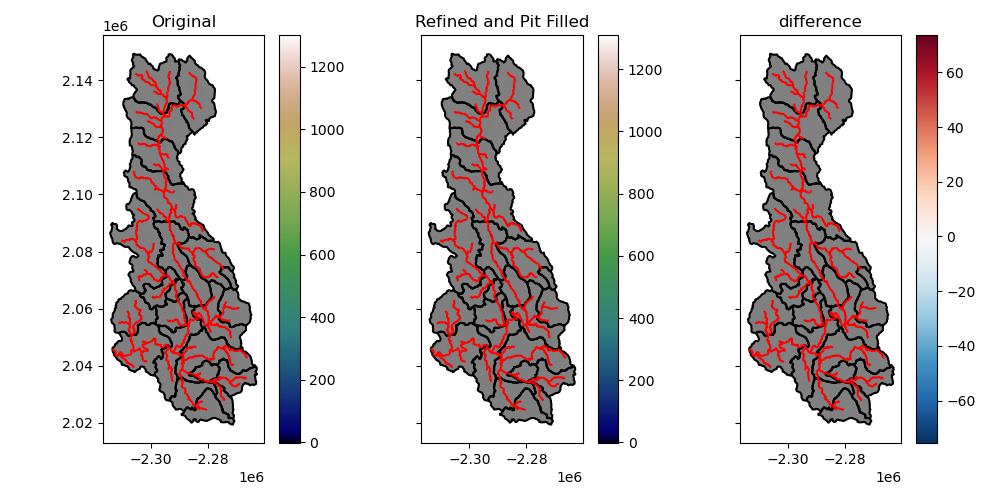

In [13]:
fig, axs = plt.subplots(1,3, sharex=True, sharey=True, figsize=(10,5))

img1 = m2_orig.plot(facecolors='elevation', cmap='gist_earth', ax=axs[0])
axs[0].set_title('Original')
img2 = m2r.plot(facecolors='elevation', cmap='gist_earth', ax=axs[1])
axs[1].set_title('Refined and Pit Filled')

# interpolate orig onto m2 for differencing
import scipy.interpolate
z_orig = scipy.interpolate.griddata(m2_orig.coords[:,0:2], m2_orig.coords[:,2], m2r.centroids[:,0:2], method='linear')
diff = m2r.centroids[:,2] - z_orig

img3 = m2r.plot(facecolors=diff, cmap='RdBu_r', ax=axs[2], vmin=diff.min(), vmax=diff.max())
axs[2].set_title('difference')

watersheds.plot(ax=axs[0], color='k')
for river in rivers:
    river.plot(ax=axs[0], color='r')
m2_orig.plot(ax=axs[0], edgecolor='grey', linewidth=0.5, facecolor='none', colorbar=False)
    
watersheds.plot(ax=axs[1], color='k')
for river in rivers:
    river.plot(ax=axs[1], color='r')
m2r.plot(ax=axs[1], edgecolor='grey', linewidth=0.5, facecolor='none', colorbar=False)

watersheds.plot(ax=axs[2], color='k')
for river in rivers:
    river.plot(ax=axs[2], color='r')
m2r.plot(ax=axs[2], edgecolor='grey', linewidth=0.5, facecolor='none', colorbar=False)

#output = widgets.Output()
output = None
scaler = watershed_workflow.dynamic_colormaps.DynamicColormapScaler(output=output)
scaler.connect(axs[0])
scaler.addGroup([img1, img2], False)
scaler.addGroup([img3,], True)

#display(output)
#for ax, img in zip(axs, [img1, img2, img3]):
#    ax.set_aspect('equal', adjustable='box')
#    divider = make_axes_locatable(ax)
#    cax = divider.append_axes("right", size="5%", pad=0.05)
#    plt.colorbar(img, cax=cax)
    
fig.canvas.draw()
plt.tight_layout()
plt.show()

In [13]:
# add regions for each polygon
watershed_workflow.regions.addWatershedAndOutletRegions(m2r, watersheds, 500)

# add regions for each stream order
watershed_workflow.regions.addStreamOrderRegions(m2r, rivers)

2026-02-04 21:16:14,706 - root - INFO: Adding regions for 24 polygons
2026-02-04 21:16:16,468 - root - INFO: Exterior outlet point (from search): POINT (-2313594.0474909726 2045820.7559020065)


In [14]:
# save the mesh and regions
with open(toOutput('m2', '03c_m2.pickle'), 'wb') as fid:
    pickle.dump(m2r, fid)

In [ ]:
np.save(toOutput('m2_centroids', 'm2_centroids.npy'), m2r.centroids)
np.save(toOutput('m2_vertices', 'm2_vertices.npy'), m2r.coords)

In [17]:
77521 in preserved_pits

True